<a href="https://colab.research.google.com/github/oridoll/Mini_projets/blob/test_vit_cnn/vit_vs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Les CNN utilisent des noyaux de convolution qui exploitent l'information locale des pixels adjacents, plus efficaces sur les petits datasets car ils ont moins de paramètres globaux à apprendre.
<p>
Les ViT utilisent le mécanisme d'auto-attention pour considérer les relations entre tous les patchs de l'image, nécessitent une grande quantité de données pour apprendre ces relations sans avoir l'avantage de l'induction locale.
<p>
[An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://doi.org/10.48550/arXiv.2010.11929) : ressources pour justifier pourquoi les CNN sont meilleurs sur les petits dataset et ViT sur les gros.

In [2]:
#%load_ext autoreload
#%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


Choix des datasets
proposition pour le premier dataset : CIFAR10 (on peut aussi envisager fashion-mnist)
https://www.cs.toronto.edu/~kriz/cifar.html
<p>Taille des images 32 x 32 pixels
<p>10 classes
<p>60 000 images (50 000 entraînement, 10 000 test)
<p>Justification du Choix
<p>Les petites images nécessitent une extraction de caractéristiques à faible niveau. Cela permet de tester si un ViT de base (qui utilise des patchs de grande taille, ex: 16x16) peut surpasser un CNN comme LeNet ou VGG sur des images peu résolues.
<p>Faible complexité -> concentrer sur l'architecture et non sur la rareté des classes.
<p>Le volume modéré permet un entraînement relativement rapide et est idéal pour tester des modèles from scratch (sans pré-entraînement) avec votre budget GPU limité.

In [9]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=True, transform=transform, download=True)
test_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=False, transform=transform, download=True)

train_loader_cifar10 = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader_cifar10 = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 26.8MB/s]


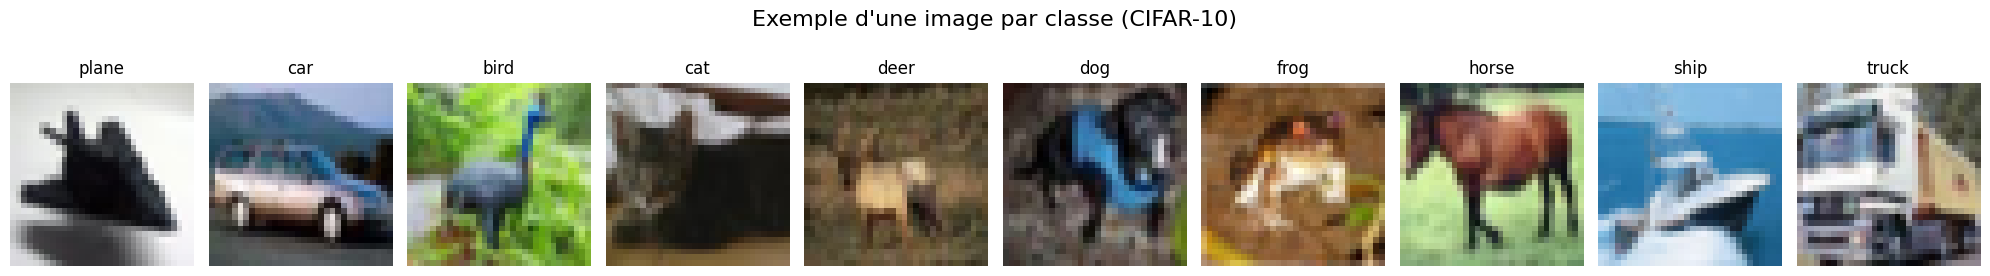


Dimensions d'une image (Tensor) : torch.Size([3, 32, 32])
Plage de valeurs d'un pixel (après ToTensor) : 0.0078 à 0.9961


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Classes from CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Collecter les indices d'une image par classes
num_classes = len(classes)
samples_per_class = 1
indices_to_display = {}

# Parcourir le dataset pour trouver un indice pour chaque classe
for i in range(len(train_dataset_cifar10)):
    _, label = train_dataset_cifar10[i]
    if label not in indices_to_display:
        indices_to_display[label] = i
        if len(indices_to_display) == num_classes:
            break

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(20, 3))
fig.suptitle("Exemple d'une image par classe (CIFAR-10)", fontsize=16)

for label, index in indices_to_display.items():
    image_tensor, _ = train_dataset_cifar10[index]

    # Convertir le Tensor PyTorch en tableau NumPy pour Matplotlib
    # Le format de CIFAR-10 est (C, H, W) (3, 32, 32), Matplotlib attend (H, W, C)
    image_np = image_tensor.numpy().transpose((1, 2, 0))

    # Affichage
    ax = axes[label]
    ax.imshow(image_np)
    ax.set_title(classes[label])
    ax.axis('off') # Supprimer les axes pour un affichage plus propre

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuster pour le titre
plt.show()

# 4. Afficher le Tensor de l'une des images pour vérification
print(f"\nDimensions d'une image (Tensor) : {image_tensor.shape}")
print(f"Plage de valeurs d'un pixel (après ToTensor) : {image_tensor.min():.4f} à {image_tensor.max():.4f}")

STL10

In [11]:
from torchvision import datasets, transforms
import torch

batch_size = 64 # On réduit la taille du batch car les images sont plus grandes

# Les images STL-10 sont de 96x96, normalisation standard.
transform_stl10 = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.43, 0.43, 0.43], std=[0.27, 0.27, 0.27])])

# Chargement de STL-10
try:
    train_dataset_stl10 = datasets.STL10(root='data_stl10', split='train', transform=transform_stl10, download=True)
    test_dataset_stl10 = datasets.STL10(root='data_stl10', split='test',transform=transform_stl10, download=True)

# Création des DataLoaders
    train_loader_stl10 = torch.utils.data.DataLoader(dataset=train_dataset_stl10, batch_size=batch_size, shuffle=True)
    test_loader_stl10 = torch.utils.data.DataLoader(dataset=test_dataset_stl10, batch_size=batch_size, shuffle=False)

    print("STL-10 chargé avec succès.")
    print(f"Images d'entraînement (étiquetées) : {len(train_dataset_stl10)}")
    print(f"Dimensions de la première image (Tensor) : {train_dataset_stl10[0][0].shape}")

except RuntimeError as e:
    print(f"Erreur lors du téléchargement de STL-10 : {e}")
    print("Veuillez vérifier votre connexion ou si le téléchargement manuel est requis (peu probable pour STL-10).")

STL-10 chargé avec succès.
Images d'entraînement (étiquetées) : 5000
Dimensions de la première image (Tensor) : torch.Size([3, 96, 96])


Affichage de 15 images aléatoires du premier batch.


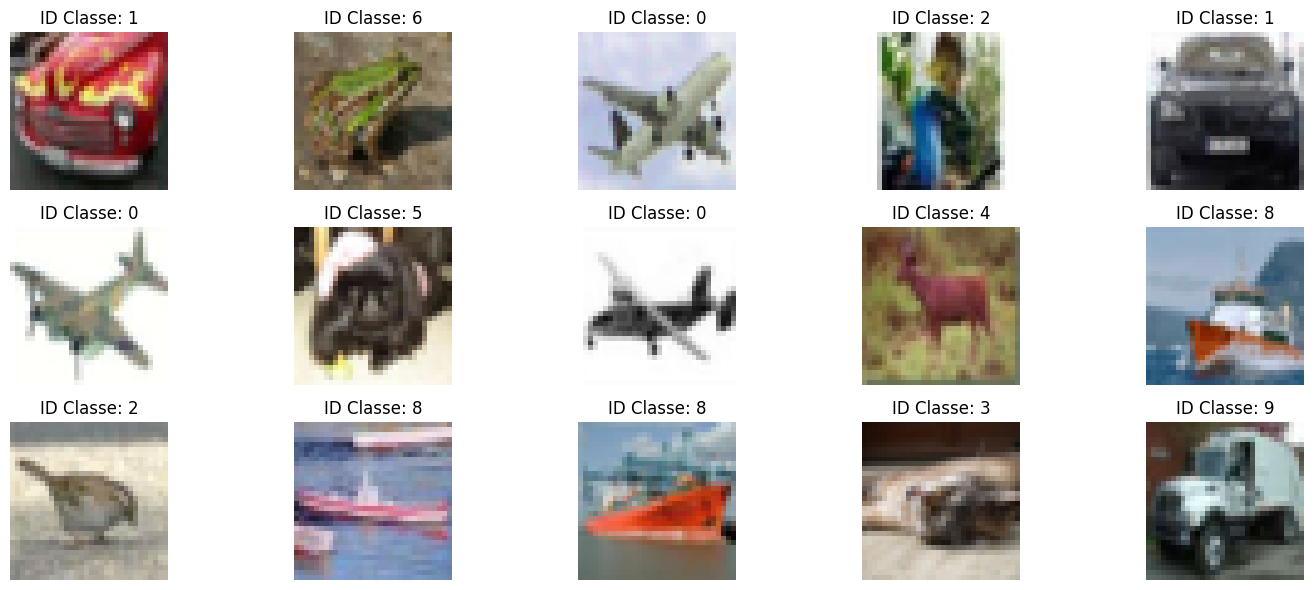


Dimensions d'un lot ImageNet : torch.Size([128, 3, 32, 32])


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Supposons que vous ayez déjà défini un ImageNet-100 ou un autre grand dataset ici
# train_loader = ... (votre DataLoader pour ImageNet-100)

# Récupérer un seul lot du DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Choisir combien d'images afficher (par exemple, 15)
num_to_display = 15

# Créer la grille d'affichage (par exemple, 3 lignes et 5 colonnes)
fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten() # Aplatir la grille d'axes pour un parcours facile

# Note : Pour un dataset comme ImageNet-100, vous devez définir votre propre liste de classes
# ou utiliser un dictionnaire pour mapper les IDs (0 à 99) aux noms réels si vous les avez.
# Pour la démo, nous afficherons les IDs numériques.
classes_ids = list(range(100)) # Simple liste des IDs 0 à 99

print(f"Affichage de {num_to_display} images aléatoires du premier batch.")

for i in range(num_to_display):
    # Convertir le Tensor (C, H, W) en NumPy (H, W, C)
    image_np = images[i].numpy().transpose((1, 2, 0))

    ax = axes[i]
    # L'affichage d'ImageNet nécessite généralement une dénormalisation si vous avez appliqué une normalisation
    # Pour l'instant, si vous utilisez seulement ToTensor(), l'affichage est direct.
    ax.imshow(image_np)

    # Afficher l'ID de la classe
    ax.set_title(f"ID Classe: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Vérification des dimensions des données ImageNet
print(f"\nDimensions d'un lot ImageNet : {images.shape}")